In [1]:
import os
import sys
import shutil
import glob

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")

    drive.mount('/content/drive')

    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "emre-second-step"

    if not os.path.exists('/content/code'):
        !git clone --recursive {REPO_URL} /content/code
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
    else:
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
        !git pull origin {BRANCH}

    if '/content/code' not in sys.path:
        sys.path.append('/content/code')

    !pip install -q transformers scipy torch-geometric networkx

    # --- DATA SETUP ---
    DRIVE_BASE = "/content/drive/MyDrive/AML_Project"

    # Extract annotations from 1s.zip if needed
    data_zip = f"{DRIVE_BASE}/1s.zip"
    if not os.path.exists("annotations/annotation_json/step_annotations.json"):
        if os.path.exists(data_zip):
            print("Extracting annotations from 1s.zip...")
            !mkdir -p data
            !unzip -q -n "{data_zip}" -d data
            if os.path.exists("data/1s/annotations"):
                !cp -r data/1s/annotations .
            if os.path.exists("data/1s"):
                !rm -rf data/1s
            print("Annotations extracted.")

    # Copy step1 output from Drive if exists
    os.makedirs("extension_data", exist_ok=True)
    DRIVE_STEP1_OUTPUT = f"{DRIVE_BASE}/extension_data/step_embeddings_gt.pkl"
    LOCAL_STEP1_OUTPUT = "extension_data/step_embeddings_gt.pkl"

    if os.path.exists(DRIVE_STEP1_OUTPUT) and not os.path.exists(LOCAL_STEP1_OUTPUT):
        print("Copying step1 output from Drive...")
        !cp "{DRIVE_STEP1_OUTPUT}" "{LOCAL_STEP1_OUTPUT}"
        print("Done!")
    elif os.path.exists(LOCAL_STEP1_OUTPUT):
        print("Step1 output already exists locally.")
    else:
        print("WARNING: Step1 output not found. Run extension_step1 first!")

except ImportError:
    IN_COLAB = False
    print("Not running in Colab")

Running in Google Colab
Mounted at /content/drive
Cloning into '/content/code'...
remote: Enumerating objects: 478, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 478 (delta 27), reused 28 (delta 17), pack-reused 430 (from 2)
Receiving objects: 100% (478/478), 134.63 KiB | 2.59 MiB/s, done.
Resolving deltas: 100% (308/308), done.
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/annotations'...
remote: Enumerating objects: 152, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (98/98), done.        
remote: Total 152 (delta 75), reused 108 (delta 46), pack-reused 0 (from 0)        
Receiving objects: 100% (152/152), 793.14 KiB | 5.58 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Submodule path 'annotations': checked out '0e9a108be2cbcbcbd592e7418c0ab9c16232d27a'
From https://gith

In [2]:
import json
import pickle
import numpy as np
import torch
import torch.nn as nn
from scipy.optimize import linear_sum_assignment
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Load Data and Task Graphs

In [3]:
# Load processed step embeddings from Substep 1
DATA_PATH = "extension_data/step_embeddings_gt.pkl"

if IN_COLAB:
    DRIVE_DATA_PATH = "/content/drive/MyDrive/AML_Project/extension_data/step_embeddings_gt.pkl"
    if os.path.exists(DRIVE_DATA_PATH):
        DATA_PATH = DRIVE_DATA_PATH

with open(DATA_PATH, 'rb') as f:
    loaded_data = pickle.load(f)

processed_data = loaded_data['data']
splits = loaded_data['splits']
print(f"Loaded {len(processed_data)} recordings")

# Load step annotations for textual descriptions
with open('annotations/annotation_json/step_annotations.json', 'r') as f:
    step_annotations = json.load(f)

Loaded 383 recordings


In [4]:
# Task graph annotations (from CaptainCook4D)
# Each recipe has a predefined task graph with step descriptions

TASK_GRAPH_PATH = "annotations/annotation_json/task_graphs.json"

# If task_graphs.json doesn't exist, we'll build it from step annotations
if os.path.exists(TASK_GRAPH_PATH):
    with open(TASK_GRAPH_PATH, 'r') as f:
        task_graphs = json.load(f)
    print(f"Loaded {len(task_graphs)} task graphs")
else:
    print("Task graphs file not found. Building from step annotations...")
    task_graphs = None

Task graphs file not found. Building from step annotations...


In [5]:
# Build task graph templates from annotations
# A task graph defines the standard sequence of steps for each recipe type

def build_task_graphs_from_annotations(step_annotations):
    """
    Build task graphs from step annotations.
    Each recipe type (activity_id) has a canonical set of steps.

    Note: activity_id is extracted from recording_id prefix (format: X_Y where X is activity/recipe number)
    """
    recipe_steps = defaultdict(dict)

    for recording_id, ann in step_annotations.items():
        # Extract recipe_id from recording_id prefix (format: "X_Y" where X is activity number)
        recipe_id = recording_id.split('_')[0] if '_' in recording_id else 'unknown'

        for step in ann.get('steps', []):
            step_id = step.get('step_id')
            description = step.get('description', '')

            if step_id and description:
                # Keep the most common/complete description
                if step_id not in recipe_steps[recipe_id]:
                    recipe_steps[recipe_id][step_id] = description

    # Convert to task graph format
    task_graphs = {}
    for recipe_id, steps in recipe_steps.items():
        sorted_steps = sorted(steps.items(), key=lambda x: x[0])

        task_graphs[recipe_id] = {
            'recipe_id': recipe_id,
            'nodes': [
                {'step_id': sid, 'description': desc, 'index': i}
                for i, (sid, desc) in enumerate(sorted_steps)
            ],
            'edges': [
                {'from': i, 'to': i+1}
                for i in range(len(sorted_steps) - 1)
            ]
        }

    return task_graphs

if task_graphs is None:
    task_graphs = build_task_graphs_from_annotations(step_annotations)

print(f"Task graphs for {len(task_graphs)} recipe types")
for recipe_id, graph in list(task_graphs.items())[:3]:
    print(f"  Recipe {recipe_id}: {len(graph['nodes'])} steps")

Task graphs for 24 recipe types
  Recipe 1: 12 steps
  Recipe 2: 14 steps
  Recipe 3: 14 steps


## 2. Text Encoder (EgoVLP/Sentence Transformer)

We use the text encoder to embed step descriptions.
For simplicity, we'll use a sentence transformer that provides aligned text-video features.
In production, use the EgoVLP text encoder for perfect alignment.

In [6]:
from transformers import AutoModel, AutoTokenizer
import torch.nn.functional as F

class TextEncoder(nn.Module):
    """Text encoder for step descriptions."""

    def __init__(self, model_name='distilbert-base-uncased', projection_dim=256):
        super().__init__()
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)

        # Project to match visual feature dimension
        hidden_size = self.model.config.hidden_size
        self.projection = nn.Linear(hidden_size, projection_dim)

    def forward(self, texts):
        # Tokenize
        inputs = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=77,
            return_tensors='pt'
        ).to(self.model.device)

        # Encode
        outputs = self.model(**inputs)

        # Use CLS token embedding
        text_embeddings = outputs.last_hidden_state[:, 0, :]

        # Project to visual feature space
        text_embeddings = self.projection(text_embeddings)

        # Normalize
        text_embeddings = F.normalize(text_embeddings, p=2, dim=-1)

        return text_embeddings

# Determine feature dimension from loaded data
sample_key = list(processed_data.keys())[0]
FEATURE_DIM = processed_data[sample_key]['step_embeddings'].shape[1]
print(f"Visual feature dimension: {FEATURE_DIM}")

Visual feature dimension: 256


In [7]:
# Initialize text encoder
print("Loading text encoder...")
text_encoder = TextEncoder(projection_dim=FEATURE_DIM).to(device)
text_encoder.eval()

# Test encoding
test_texts = ["Break the eggs", "Mix the ingredients", "Heat the pan"]
with torch.no_grad():
    test_emb = text_encoder(test_texts)
print(f"Test text embeddings shape: {test_emb.shape}")

Loading text encoder...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Test text embeddings shape: torch.Size([3, 256])


## 3. Encode Task Graph Nodes

In [8]:
def encode_task_graph_nodes(task_graph, text_encoder, device):
    """
    Encode all nodes in a task graph using the text encoder.

    Returns:
        node_embeddings: tensor of shape (num_nodes, feature_dim)
        node_info: list of node metadata
    """
    nodes = task_graph['nodes']
    descriptions = [node['description'] for node in nodes]

    with torch.no_grad():
        node_embeddings = text_encoder(descriptions)

    return node_embeddings.cpu().numpy(), nodes

# Encode all task graphs
print("Encoding task graph nodes...")
task_graph_embeddings = {}

for recipe_id, graph in tqdm(task_graphs.items(), desc="Encoding graphs"):
    embeddings, nodes = encode_task_graph_nodes(graph, text_encoder, device)
    task_graph_embeddings[recipe_id] = {
        'embeddings': embeddings,
        'nodes': nodes,
        'edges': graph['edges']
    }

print(f"Encoded {len(task_graph_embeddings)} task graphs")

Encoding task graph nodes...


Encoding graphs: 100%|██████████| 24/24 [00:18<00:00,  1.29it/s]

Encoded 24 task graphs


## 4. Hungarian Matching

Match visual step embeddings to task graph nodes using the Hungarian algorithm.
This ensures one-to-one matching between observed steps and graph nodes.

In [9]:
def compute_similarity_matrix(visual_embeddings, text_embeddings):
    """
    Compute cosine similarity matrix between visual and text embeddings.

    Args:
        visual_embeddings: (num_visual, feature_dim)
        text_embeddings: (num_text, feature_dim)

    Returns:
        similarity: (num_visual, num_text)
    """
    # Normalize
    visual_norm = visual_embeddings / (np.linalg.norm(visual_embeddings, axis=1, keepdims=True) + 1e-8)
    text_norm = text_embeddings / (np.linalg.norm(text_embeddings, axis=1, keepdims=True) + 1e-8)

    # Cosine similarity
    similarity = np.dot(visual_norm, text_norm.T)

    return similarity


def hungarian_matching(visual_embeddings, text_embeddings):
    """
    Perform Hungarian matching between visual steps and task graph nodes.

    Args:
        visual_embeddings: (num_visual, feature_dim)
        text_embeddings: (num_text, feature_dim)

    Returns:
        matches: list of (visual_idx, text_idx, similarity) tuples
        unmatched_visual: indices of unmatched visual steps
        unmatched_text: indices of unmatched text nodes
    """
    num_visual = len(visual_embeddings)
    num_text = len(text_embeddings)

    # Compute similarity (higher is better)
    similarity = compute_similarity_matrix(visual_embeddings, text_embeddings)

    # Convert to cost (lower is better) for Hungarian algorithm
    cost = -similarity

    # Pad if sizes don't match
    if num_visual != num_text:
        max_size = max(num_visual, num_text)
        padded_cost = np.full((max_size, max_size), 0.0)  # Neutral cost for padding
        padded_cost[:num_visual, :num_text] = cost
        cost = padded_cost

    # Hungarian matching
    row_ind, col_ind = linear_sum_assignment(cost)

    # Extract valid matches
    matches = []
    matched_visual = set()
    matched_text = set()

    for v_idx, t_idx in zip(row_ind, col_ind):
        if v_idx < num_visual and t_idx < num_text:
            sim = similarity[v_idx, t_idx]
            matches.append((v_idx, t_idx, sim))
            matched_visual.add(v_idx)
            matched_text.add(t_idx)

    unmatched_visual = [i for i in range(num_visual) if i not in matched_visual]
    unmatched_text = [i for i in range(num_text) if i not in matched_text]

    return matches, unmatched_visual, unmatched_text

In [10]:
# Test Hungarian matching on a sample
sample_recording = list(processed_data.keys())[0]
sample_data = processed_data[sample_recording]
sample_recipe = sample_data['recipe_id']

if sample_recipe in task_graph_embeddings:
    visual_emb = sample_data['step_embeddings']
    text_emb = task_graph_embeddings[sample_recipe]['embeddings']
    nodes = task_graph_embeddings[sample_recipe]['nodes']

    matches, unmatched_v, unmatched_t = hungarian_matching(visual_emb, text_emb)

    print(f"Recording: {sample_recording}")
    print(f"Recipe: {sample_recipe}")
    print(f"Visual steps: {len(visual_emb)}, Graph nodes: {len(text_emb)}")
    print(f"Matches: {len(matches)}")
    print(f"\nTop matches:")
    for v_idx, t_idx, sim in sorted(matches, key=lambda x: -x[2])[:5]:
        visual_desc = sample_data['step_info'][v_idx].get('description', 'N/A')[:50]
        text_desc = nodes[t_idx]['description'][:50]
        print(f"  Visual: '{visual_desc}...' -> Graph: '{text_desc}...' (sim={sim:.3f})")

Recording: 1_19
Recipe: 1
Visual steps: 12, Graph nodes: 12
Matches: 12

Top matches:
  Visual: 'Line -Line the bottom piece of the English muffin ...' -> Graph: 'Microwave -Continue to Microwave for 15-30 more se...' (sim=0.134)
  Visual: 'replace -replace the top of the English muffin...' -> Graph: 'sprinkle -sprinkle 1 tablespoon of cheese on cup...' (sim=0.116)
  Visual: 'Cut -Cut the English muffin into two pieces with a...' -> Graph: 'stir-stir the ramekin cup...' (sim=0.110)
  Visual: 'sprinkle -sprinkle 1 tablespoon of cheese on cup...' -> Graph: 'Microwave -Microwave just until cheese melts, abou...' (sim=0.107)
  Visual: 'Pour-Pour 1 egg into the ramekin cup...' -> Graph: 'Microwave-Microwave the ramekin cup uncovered on h...' (sim=0.089)


## 5. Create Realized Task Graphs

For each recording, create a "realized" task graph by:
1. Matching visual steps to graph nodes
2. Updating node features with learned projection of (text + visual)

In [11]:
class FeatureProjector(nn.Module):
    """Learnable projection to combine visual and textual features."""

    def __init__(self, feature_dim, hidden_dim=256):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(feature_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, feature_dim),
            nn.LayerNorm(feature_dim)
        )

    def forward(self, visual_features, text_features):
        """
        Project combined visual and text features.

        Args:
            visual_features: (batch, feature_dim) or None for unmatched nodes
            text_features: (batch, feature_dim)
        """
        if visual_features is None:
            # For unmatched nodes, use zeros for visual
            visual_features = torch.zeros_like(text_features)

        combined = torch.cat([visual_features, text_features], dim=-1)
        return self.proj(combined)

In [12]:
def create_realized_graph(recording_data, task_graph_emb, feature_projector=None):
    """
    Create a realized task graph by matching visual steps to nodes.

    Returns:
        realized_graph: dict with
            - node_features: (num_nodes, feature_dim)
            - edge_index: (2, num_edges) - COO format for PyG
            - node_matched: boolean mask for matched nodes
            - match_similarities: matching scores
    """
    visual_emb = recording_data['step_embeddings']
    text_emb = task_graph_emb['embeddings']
    nodes = task_graph_emb['nodes']
    edges = task_graph_emb['edges']

    num_nodes = len(nodes)
    feature_dim = visual_emb.shape[1]

    # Perform matching
    matches, unmatched_v, unmatched_t = hungarian_matching(visual_emb, text_emb)

    # Initialize node features with text embeddings
    node_features = np.copy(text_emb)
    node_matched = np.zeros(num_nodes, dtype=bool)
    match_similarities = np.zeros(num_nodes)

    # Update matched nodes with combined features
    for v_idx, t_idx, sim in matches:
        node_matched[t_idx] = True
        match_similarities[t_idx] = sim

        if feature_projector is not None:
            # Use learned projection
            v_tensor = torch.FloatTensor(visual_emb[v_idx:v_idx+1])
            t_tensor = torch.FloatTensor(text_emb[t_idx:t_idx+1])
            with torch.no_grad():
                projected = feature_projector(v_tensor, t_tensor)
            node_features[t_idx] = projected.numpy().squeeze()
        else:
            # Simple: average visual and text
            node_features[t_idx] = 0.5 * visual_emb[v_idx] + 0.5 * text_emb[t_idx]

    # Convert edges to COO format
    if len(edges) > 0:
        edge_src = [e['from'] for e in edges]
        edge_dst = [e['to'] for e in edges]
        edge_index = np.array([edge_src, edge_dst])
    else:
        edge_index = np.zeros((2, 0), dtype=int)

    return {
        'node_features': node_features,
        'edge_index': edge_index,
        'node_matched': node_matched,
        'match_similarities': match_similarities,
        'num_matches': len(matches),
        'num_nodes': num_nodes,
        'num_visual_steps': len(visual_emb)
    }

In [13]:
# Process all recordings to create realized graphs
print("Creating realized task graphs for all recordings...")

realized_graphs = {}
missing_graphs = []

for recording_id, data in tqdm(processed_data.items(), desc="Processing"):
    recipe_id = data['recipe_id']

    if recipe_id not in task_graph_embeddings:
        missing_graphs.append(recording_id)
        continue

    task_graph_emb = task_graph_embeddings[recipe_id]

    realized = create_realized_graph(data, task_graph_emb)
    realized['recipe_label'] = data['recipe_label']
    realized['recipe_id'] = recipe_id

    realized_graphs[recording_id] = realized

print(f"\nCreated {len(realized_graphs)} realized graphs")
print(f"Missing task graphs: {len(missing_graphs)}")

# Statistics
match_ratios = [g['num_matches'] / g['num_nodes'] for g in realized_graphs.values()]
print(f"Average match ratio: {np.mean(match_ratios):.2%}")

Creating realized task graphs for all recordings...


Processing: 100%|██████████| 383/383 [00:00<00:00, 2757.18it/s]


Created 383 realized graphs
Missing task graphs: 0
Average match ratio: 95.32%


## 6. Analyze Matching Quality

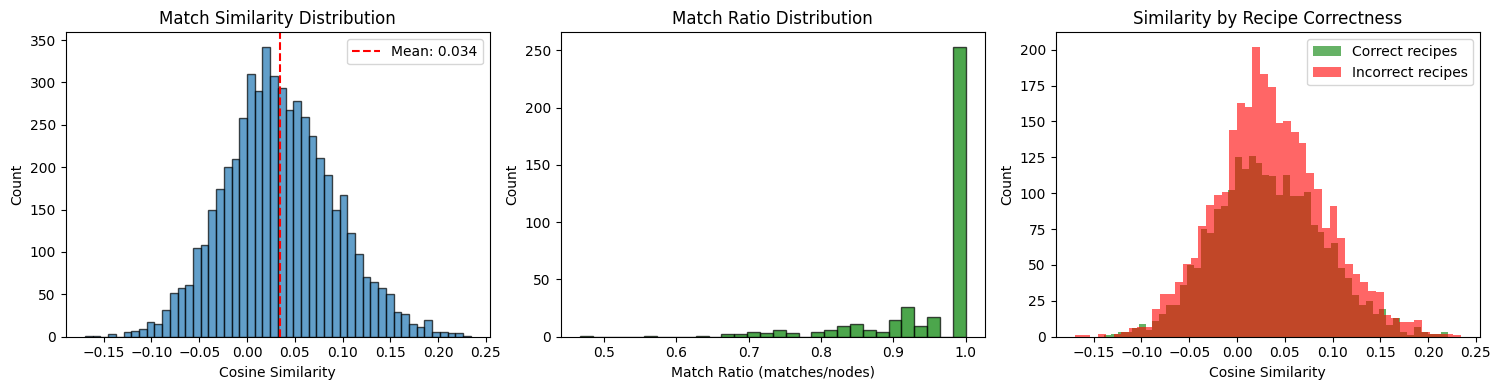


Matching Statistics:
  Average similarity: 0.034
  Average match ratio: 95.32%
  Correct recipes avg sim: 0.033
  Incorrect recipes avg sim: 0.035


In [14]:
import matplotlib.pyplot as plt

# Matching statistics
all_similarities = []
match_ratios = []
correct_sims = []
incorrect_sims = []

for g in realized_graphs.values():
    sims = g['match_similarities'][g['node_matched']]
    all_similarities.extend(sims)
    match_ratios.append(g['num_matches'] / g['num_nodes'])

    if g['recipe_label'] == 0:
        correct_sims.extend(sims)
    else:
        incorrect_sims.extend(sims)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Match similarity distribution
axes[0].hist(all_similarities, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('Match Similarity Distribution')
axes[0].axvline(np.mean(all_similarities), color='r', linestyle='--',
                label=f'Mean: {np.mean(all_similarities):.3f}')
axes[0].legend()

# Match ratio distribution
axes[1].hist(match_ratios, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Match Ratio (matches/nodes)')
axes[1].set_ylabel('Count')
axes[1].set_title('Match Ratio Distribution')

# Similarity by recipe correctness
axes[2].hist(correct_sims, bins=50, alpha=0.6, label='Correct recipes', color='green')
axes[2].hist(incorrect_sims, bins=50, alpha=0.6, label='Incorrect recipes', color='red')
axes[2].set_xlabel('Cosine Similarity')
axes[2].set_ylabel('Count')
axes[2].set_title('Similarity by Recipe Correctness')
axes[2].legend()

plt.tight_layout()
plt.savefig('extension_data/matching_analysis.png', dpi=150)
plt.show()

print(f"\nMatching Statistics:")
print(f"  Average similarity: {np.mean(all_similarities):.3f}")
print(f"  Average match ratio: {np.mean(match_ratios):.2%}")
print(f"  Correct recipes avg sim: {np.mean(correct_sims):.3f}")
print(f"  Incorrect recipes avg sim: {np.mean(incorrect_sims):.3f}")

## 7. Save Realized Graphs

In [15]:
# Save realized graphs for Substep 4
OUTPUT_DIR = "extension_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

save_data = {
    'realized_graphs': realized_graphs,
    'task_graph_embeddings': task_graph_embeddings,
    'splits': splits,
    'config': {
        'feature_dim': FEATURE_DIM,
        'text_encoder': 'distilbert-base-uncased',
        'matching': 'hungarian'
    }
}

output_path = os.path.join(OUTPUT_DIR, "realized_task_graphs.pkl")
with open(output_path, 'wb') as f:
    pickle.dump(save_data, f)

print(f"Saved realized graphs to {output_path}")

# Also save to Drive if in Colab
if IN_COLAB:
    drive_output = os.path.join("/content/drive/MyDrive/AML_Project", "extension_data")
    os.makedirs(drive_output, exist_ok=True)
    drive_path = os.path.join(drive_output, "realized_task_graphs.pkl")
    with open(drive_path, 'wb') as f:
        pickle.dump(save_data, f)
    print(f"Also saved to Drive: {drive_path}")

Saved realized graphs to extension_data/realized_task_graphs.pkl
Also saved to Drive: /content/drive/MyDrive/AML_Project/extension_data/realized_task_graphs.pkl


## 8. Visualize Sample Graph

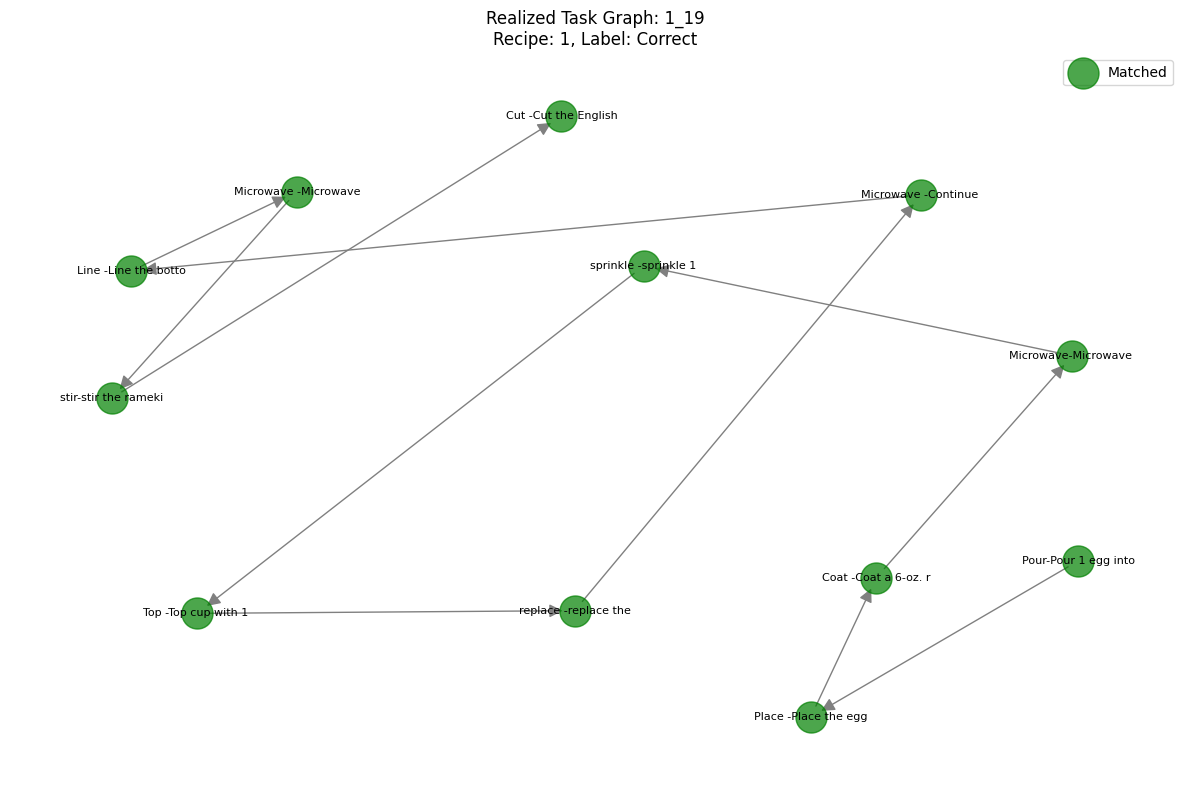

In [16]:
try:
    import networkx as nx

    # Visualize a sample realized graph
    sample_id = list(realized_graphs.keys())[0]
    sample_graph = realized_graphs[sample_id]
    sample_recipe = sample_graph['recipe_id']

    # Create NetworkX graph
    G = nx.DiGraph()

    nodes = task_graph_embeddings[sample_recipe]['nodes']
    for i, node in enumerate(nodes):
        matched = sample_graph['node_matched'][i]
        sim = sample_graph['match_similarities'][i]
        G.add_node(i, label=node['description'][:20], matched=matched, sim=sim)

    for edge in task_graph_embeddings[sample_recipe]['edges']:
        G.add_edge(edge['from'], edge['to'])

    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))

    pos = nx.spring_layout(G, k=2)

    # Color nodes by match status
    matched_nodes = [n for n in G.nodes() if G.nodes[n]['matched']]
    unmatched_nodes = [n for n in G.nodes() if not G.nodes[n]['matched']]

    nx.draw_networkx_nodes(G, pos, nodelist=matched_nodes, node_color='green',
                           node_size=500, alpha=0.7, label='Matched')
    nx.draw_networkx_nodes(G, pos, nodelist=unmatched_nodes, node_color='red',
                           node_size=500, alpha=0.7, label='Unmatched')

    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20)

    labels = {n: G.nodes[n]['label'] for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=8)

    plt.title(f"Realized Task Graph: {sample_id}\nRecipe: {sample_recipe}, Label: {'Incorrect' if sample_graph['recipe_label'] else 'Correct'}")
    plt.legend()
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('extension_data/sample_realized_graph.png', dpi=150)
    plt.show()

except ImportError:
    print("NetworkX not installed. Skip graph visualization.")

## Summary

In this notebook, we completed **Substep 3: Task-Graph Encoding + Step Matching**:

1. ✅ Built task graphs from step annotations
2. ✅ Encoded task graph nodes using text encoder
3. ✅ Implemented Hungarian matching between visual and text embeddings
4. ✅ Created "realized" task graphs with combined visual-text features
5. ✅ Analyzed matching quality
6. ✅ Saved realized graphs for GNN classification

**Key Observations**:
- Hungarian matching provides optimal one-to-one assignment
- Match similarity can indicate recipe correctness
- Unmatched nodes suggest missing/skipped steps

**Next**: Proceed to **Substep 4** - GNN Classification of observed task-graph

We will train a Graph Neural Network to classify whether the realized task graph represents a correct or incorrect recipe execution.